<a href="https://colab.research.google.com/github/z55vz/DL_Project/blob/main/DynamicPricing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


========== MODEL PERFORMANCE ==========
                 Model       AUC  Brier Score
0  Logistic Regression  0.943767     0.091907
1  Deep Neural Network  0.956111     0.084759


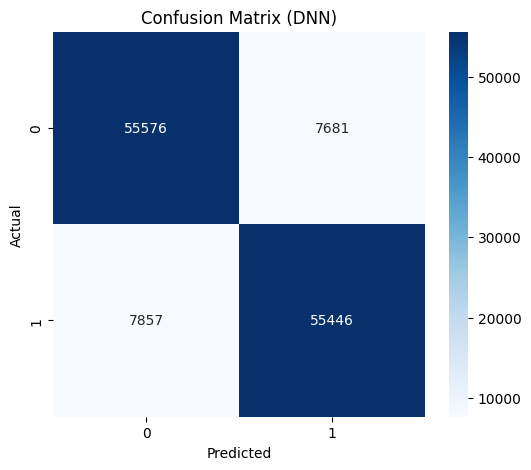

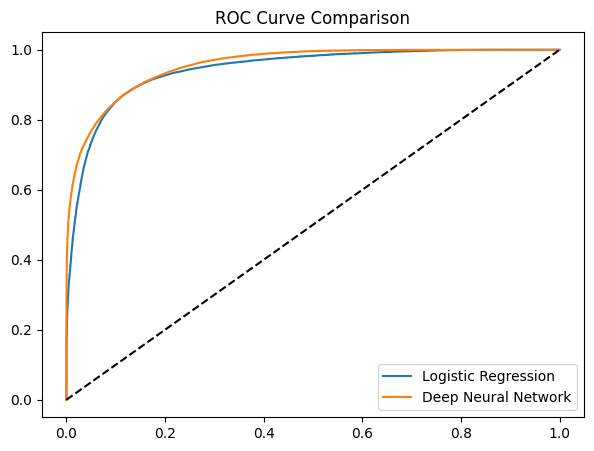

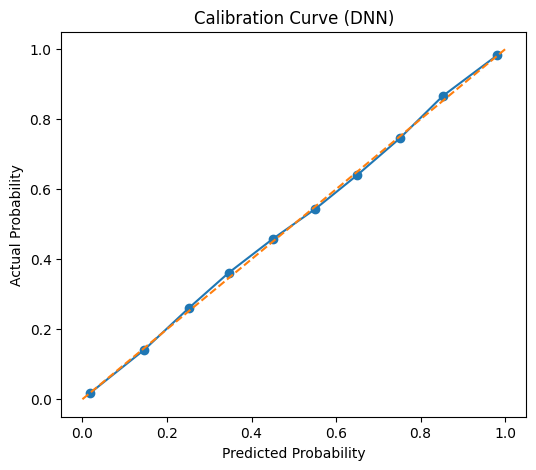


========== REVENUE ANALYSIS ==========
Base Revenue: 6.521
Optimized Revenue: 9.768
Improvement: 49.80%

========== SAMPLE OUTPUT ==========
       distance_km     p_base  Optimal_Price            Strategy
31975     8.500000  14.800000      13.138776  Demand Stimulation
38058     9.166667  15.333333      13.925170  Demand Stimulation
16678     4.600000  11.680000       9.177143  Demand Stimulation
36876     7.766667  14.213333      12.327891  Demand Stimulation
50926     3.266667  10.613333       8.555646  Demand Stimulation
776       0.966667   8.773333       9.400000    Premium Strategy
20793     1.044444   8.835556       9.466667    Premium Strategy
63089     1.277778   9.022222       9.666667    Premium Strategy
37519     1.522222   9.217778       9.688073    Premium Strategy


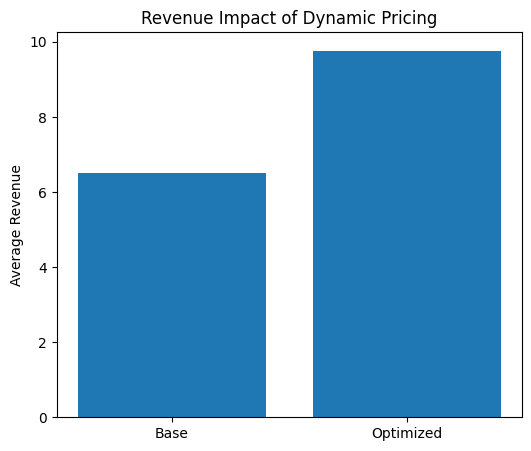

In [1]:
# PROJECT: AI-Based Dynamic Pricing for Delivery Services
# AUTHOR: Abdulrahman Jaber Ageeli
# UNIVERSITY: Umm Al-Qura University
# DESCRIPTION: This project applies machine learning and deep learning to estimate
# customer acceptance probability for delivery prices and optimize pricing in order
# to maximize expected revenue.

# Import required libraries for data processing, modeling, and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, brier_score_loss, roc_curve, confusion_matrix
from sklearn.calibration import calibration_curve

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

# Set random seeds to ensure reproducible results
np.random.seed(42)
tf.random.set_seed(42)

# Load dataset and select relevant columns
df = pd.read_csv("historical_data.csv")
df = df[["created_at", "estimated_store_to_consumer_driving_duration"]].dropna()

# Convert timestamps and extract hour-based features
df["created_at"] = pd.to_datetime(df["created_at"])
df["hour"] = df["created_at"].dt.hour

# Create peak-hour indicator based on demand patterns
df["is_peak"] = (
    ((df["hour"] >= 11) & (df["hour"] <= 14)) |
    ((df["hour"] >= 18) & (df["hour"] <= 21))
).astype(int)

# Estimate delivery distance using duration and average city speed
AVG_CITY_SPEED = 40
df["distance_km"] = (df["estimated_store_to_consumer_driving_duration"] / 3600) * AVG_CITY_SPEED
df = df[df["distance_km"] > 0].copy()

# Simulate weather conditions that influence customer behavior
rain_probability = 0.2 + 0.1 * df["is_peak"]
df["is_rainy"] = (np.random.rand(len(df)) < rain_probability).astype(int)

# Define a base delivery price as a function of distance
df["p_base"] = 8 + 0.8 * df["distance_km"]

# Split dataset into training and testing subsets
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Simulate customer decisions under different pricing scenarios
def simulate_market(data, n_prices=10):
    data_rep = pd.concat([data] * n_prices, ignore_index=True)
    n = len(data_rep)

    alpha = (
        0.15
        + 0.05 * data_rep["distance_km"]
        + 0.02 * (data_rep["distance_km"] ** 2)
        + 0.08 * data_rep["distance_km"] * data_rep["is_rainy"]
        - 0.07 * data_rep["is_peak"]
    )

    delta = np.random.uniform(-0.5 * data_rep["p_base"], 0.5 * data_rep["p_base"], n)
    price = np.maximum(2.0, data_rep["p_base"] + delta)

    eps = np.random.normal(0, 0.5, n)

    z = -alpha * (price - data_rep["p_base"]) + eps
    p_accept = 1 / (1 + np.exp(-z))

    target = (np.random.rand(n) < p_accept).astype(int)

    return pd.DataFrame({
        "distance": data_rep["distance_km"],
        "is_peak": data_rep["is_peak"],
        "is_rainy": data_rep["is_rainy"],
        "price": price,
        "p_base": data_rep["p_base"],
        "target": target
    })

# Generate simulated training and testing data
train_sim = simulate_market(train_df)
test_sim = simulate_market(test_df)

# Define model input features
features = ["distance", "is_peak", "is_rainy", "price", "p_base"]

X_train = train_sim[features]
X_test = test_sim[features]
y_train = train_sim["target"]
y_test = test_sim["target"]

# Normalize features to improve model training stability
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train a logistic regression model as a baseline
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train_scaled, y_train)
lr_probs = logistic_model.predict_proba(X_test_scaled)[:, 1]

# Build a deep neural network with regularization for better generalization
dnn = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(128, activation="relu", kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation="relu", kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation="relu", kernel_regularizer=l2(1e-4)),
    Dense(1, activation="sigmoid")
])

# Compile the neural network using binary classification loss
dnn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["AUC"])

# Apply early stopping to prevent overfitting during training
early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

# Train the neural network using a validation split
dnn.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=1024,
    callbacks=[early_stop],
    verbose=0
)

# Generate probability predictions from both models
dnn_probs = dnn.predict(X_test_scaled, batch_size=2048, verbose=0).ravel()

# Evaluate classification performance using AUC and Brier score
lr_auc = roc_auc_score(y_test, lr_probs)
dnn_auc = roc_auc_score(y_test, dnn_probs)

lr_brier = brier_score_loss(y_test, lr_probs)
dnn_brier = brier_score_loss(y_test, dnn_probs)

print("\n========== MODEL PERFORMANCE ==========")
print(pd.DataFrame({
    "Model": ["Logistic Regression", "Deep Neural Network"],
    "AUC": [lr_auc, dnn_auc],
    "Brier Score": [lr_brier, dnn_brier]
}))

# Visualize confusion matrix as a heatmap for classification insight
threshold = 0.5
y_pred = (dnn_probs >= threshold).astype(int)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (DNN)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Plot ROC curves to compare model discrimination ability
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_dnn, tpr_dnn, _ = roc_curve(y_test, dnn_probs)

plt.figure(figsize=(7,5))
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_dnn, tpr_dnn, label="Deep Neural Network")
plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# Plot calibration curve to evaluate probability reliability
prob_true, prob_pred = calibration_curve(y_test, dnn_probs, n_bins=10)

plt.figure(figsize=(6,5))
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--')
plt.title("Calibration Curve (DNN)")
plt.xlabel("Predicted Probability")
plt.ylabel("Actual Probability")
plt.show()

# Optimize pricing decisions to maximize expected revenue
N = 500
sample = test_df.head(N).copy()

base_prices = sample["p_base"].values
price_grid = np.linspace(0.5, 1.5, 50)

best_revenue = np.zeros(N)
best_price = np.zeros(N)

for factor in price_grid:
    candidate_prices = base_prices * factor

    X_opt = pd.DataFrame({
        "distance": sample["distance_km"],
        "is_peak": sample["is_peak"],
        "is_rainy": sample["is_rainy"],
        "price": candidate_prices,
        "p_base": base_prices
    })

    probs = dnn.predict(scaler.transform(X_opt), verbose=0).ravel()
    revenue = candidate_prices * probs

    mask = revenue > best_revenue
    best_revenue[mask] = revenue[mask]
    best_price[mask] = candidate_prices[mask]

# Compute baseline revenue for comparison
X_base = X_opt.copy()
X_base["price"] = base_prices

base_probs = dnn.predict(scaler.transform(X_base), verbose=0).ravel()
base_revenue = base_prices * base_probs

avg_base = np.mean(base_revenue)
avg_opt = np.mean(best_revenue)

print("\n========== REVENUE ANALYSIS ==========")
print(f"Base Revenue: {avg_base:.3f}")
print(f"Optimized Revenue: {avg_opt:.3f}")
print(f"Improvement: {((avg_opt-avg_base)/avg_base)*100:.2f}%")

# Assign pricing strategy labels based on optimal pricing decisions
sample["Optimal_Price"] = best_price
sample["Optimized_Revenue"] = best_revenue

sample["Strategy"] = np.where(
    sample["Optimal_Price"] < sample["p_base"],
    "Demand Stimulation",
    "Premium Strategy"
)

# Display a balanced sample showing both strategies when available
print("\n========== SAMPLE OUTPUT ==========")

demand_sample = sample[sample["Strategy"] == "Demand Stimulation"].head(5)
premium_sample = sample[sample["Strategy"] == "Premium Strategy"].head(5)

final_sample = pd.concat([demand_sample, premium_sample])

print(final_sample[["distance_km", "p_base", "Optimal_Price", "Strategy"]])

# Visualize revenue improvement using a bar chart
plt.figure(figsize=(6,5))
plt.bar(["Base","Optimized"], [avg_base, avg_opt])
plt.title("Revenue Impact of Dynamic Pricing")
plt.ylabel("Average Revenue")
plt.show()